In [1]:
import sys
from pathlib import Path

# Add project root to path so src module can be imported
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Data Preparation & Noise Injection
Load ImageNet-100, inspect samples, apply corruption strategies, and build train/val/test dataloaders.

In [2]:
from pathlib import Path
import yaml
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

from src.dataset import ImageNet100Dataset, NoiseInjector, get_dataloaders

In [3]:
config_path = Path('../configs/config.yaml')
with config_path.open('r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Make dataset root path absolute relative to project root
if not Path(config['dataset']['root']).is_absolute():
    config['dataset']['root'] = str(project_root / config['dataset']['root'])

config

{'dataset': {'name': 'imagenet100',
  'root': 'c:\\Users\\Akash\\Desktop\\SelfHealingNN\\data\\raw',
  'image_size': 224,
  'num_classes': 100,
  'train_split': 0.8},
 'noise': {'types': ['gaussian', 'salt_pepper', 'occlusion'],
  'gaussian_std': 0.2,
  'salt_pepper_prob': 0.1,
  'occlusion_size': 32},
 'vae': {'latent_dim': 256,
  'encoder_channels': [64, 128, 256, 512],
  'beta': 0.2,
  'learning_rate': 0.0001,
  'epochs': 50,
  'batch_size': 16,
  'denormalize_targets': True,
  'disable_amp_until_stable': True,
  'beta_schedule': 'linear_warmup',
  'beta_warmup_epochs': 10,
  'recon_loss_type': 'smooth_l1',
  'huber_delta': 1.0},
 'classifier': {'backbone': 'resnet18',
  'pretrained': True,
  'learning_rate': 0.0001,
  'epochs': 30,
  'batch_size': 32},
 'training': {'device': 'cuda',
  'num_workers': 6,
  'save_every': 5,
  'early_stopping_patience': 10,
  'checkpoint_interval': 2,
  'auto_resume': True,
  'amp': True,
  'grad_clip_norm': 1.0,
  'vae_early_stop_metric': 'val_recon'

In [4]:
root = Path(config['dataset']['root'])
if not root.exists():
    print(f'ImageNet-100 root not found at: {root.resolve()}')
    print('Create class folders under data/raw before training.')
else:
    class_dirs = sorted([p.name for p in root.iterdir() if p.is_dir()])
    print(f'Found {len(class_dirs)} class folders.')
    print('Sample classes:', class_dirs[:10])

Found 2 class folders.
Sample classes: ['train', 'val']


In [5]:
injector = NoiseInjector()
injector

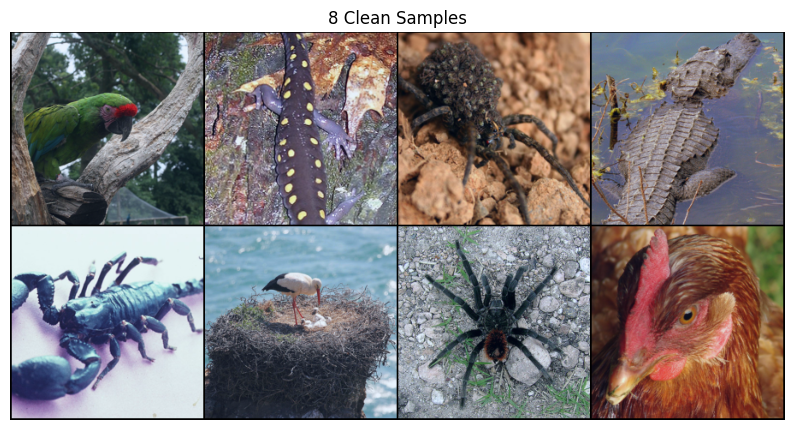

In [6]:
dataset = ImageNet100Dataset(root=config['dataset']['root'], image_size=config['dataset']['image_size'])
idx = torch.randperm(len(dataset))[:8]
clean_images = torch.stack([dataset[int(i)][0] for i in idx])

grid = make_grid(clean_images, nrow=4, normalize=True)
plt.figure(figsize=(10, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.title('8 Clean Samples')
plt.axis('off')
plt.show()

In [7]:
print(f'Dataset root path: {config["dataset"]["root"]}')
print(f'Path exists: {Path(config["dataset"]["root"]).exists()}')
print(f'Project root: {project_root}')

Dataset root path: c:\Users\Akash\Desktop\SelfHealingNN\data\raw
Path exists: True
Project root: c:\Users\Akash\Desktop\SelfHealingNN


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


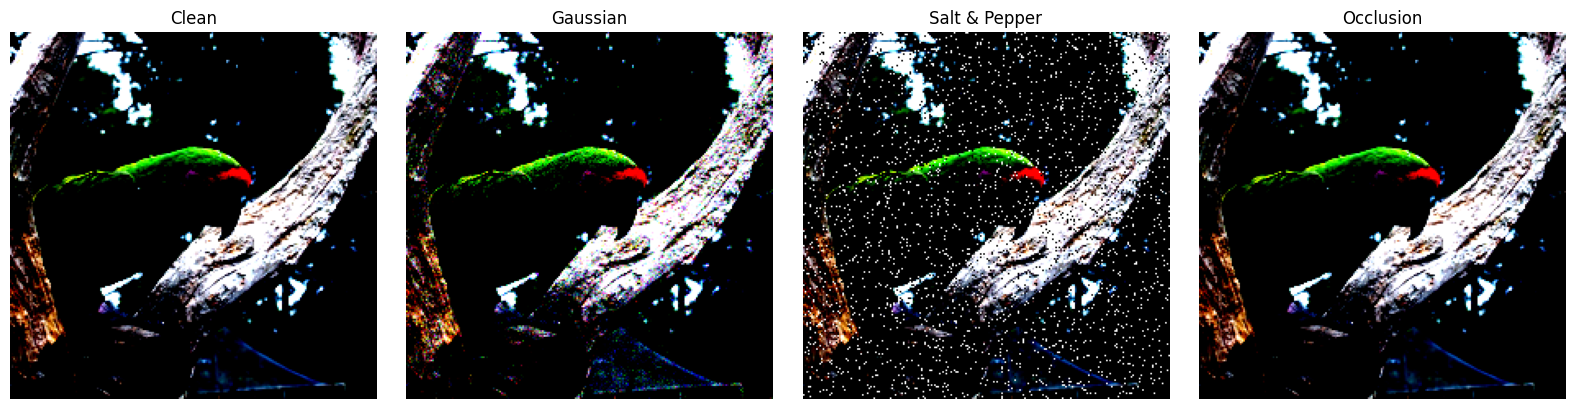

In [8]:
sample = clean_images[0]
gaussian = injector.add_gaussian_noise(sample, std=config['noise']['gaussian_std'])
salt_pepper = injector.add_salt_pepper(sample, prob=config['noise']['salt_pepper_prob'])
occluded = injector.add_occlusion(sample, patch_size=config['noise']['occlusion_size'])

compare = torch.stack([sample, gaussian, salt_pepper, occluded])
titles = ['Clean', 'Gaussian', 'Salt & Pepper', 'Occlusion']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.imshow(compare[i].permute(1, 2, 0).detach().cpu().numpy(), vmin=-2, vmax=2)
    ax.set_title(titles[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
train_loader, val_loader, test_loader = get_dataloaders(
    root=config['dataset']['root'],
    image_size=config['dataset']['image_size'],
    batch_size=config['vae']['batch_size'],
    train_split=config['dataset']['train_split'],
    num_workers=config['training']['num_workers'],
    noisy=True,
    noise_type='gaussian',
    noise_params={'std': config['noise']['gaussian_std']}
)

noisy_batch, clean_batch, labels = next(iter(train_loader))
print('Noisy batch shape:', noisy_batch.shape)
print('Clean batch shape:', clean_batch.shape)
print('Labels shape:', labels.shape)

Noisy batch shape: torch.Size([16, 3, 224, 224])
Clean batch shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])


## Summary
ImageNet-100 loading, corruption injection, visualization, and dataloader preparation are now ready for model training stages.